# 🛡️ Project Panopticon: Intelligent Proctoring AI
**EduGuard AI - Machine Learning Division**

**Intern Name:** `[vivek sahu]`  
**Date:** `[30/09/2026]`

---

### 📖 Executive Summary
Welcome to EduGuard AI. Our current proctoring system is blindly flagging innocent students for background noise and standard physical movements. Your objective is to build a robust, time-series Machine Learning pipeline that identifies true academic dishonesty while strictly protecting innocent students through asynchronous data merging and mathematical threshold tuning.

### 🗺️ Project Roadmap
1. **Data Ingestion:** Upload and parse asynchronous telemetry logs.
2. **Temporal Alignment:** Merge video and system logs using `merge_asof`.
3. **Signal Processing:** Impute missing data and engineer rolling windows.
4. **Classification:** Train an imbalanced-weighted predictive model.
5. **Ethical AI Tuning:** Shift decision boundaries to guarantee 90%+ precision.

In [1]:
# ==========================================
# 0. IMPORT LIBRARIES
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn Imports
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, precision_score, recall_score

# Set visualization styles
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("✅ Libraries imported successfully.")

✅ Libraries imported successfully.


---
## Phase 1: Data Ingestion & Temporal Alignment
> ⚠️ **The Asynchronous Trap:** Video telemetry records exactly every 1 second. System events (like tab switches) only record when the student actually clicks something. You cannot use a standard `pd.merge()`.

**Instructions:**
1. Upload the `video_telemetry.csv` and `system_events.csv` files.
2. Convert the timestamp columns to datetime objects.
3. Sort the dataframes and merge them using Pandas `merge_asof`.

In [3]:
# ==========================================
# 1A. UPLOAD DATASETS (Google Colab Only)
# ==========================================
# If running locally, you can comment this block out.

try:
    from google.colab import files
    print("📂 Please upload 'video_telemetry.csv' and 'system_events.csv'...")
    uploaded = files.upload()

    # Get the actual uploaded filenames
    video_filename = [name for name in uploaded.keys() if 'video_telemetry' in name][0]
    sys_filename = [name for name in uploaded.keys() if 'system_events' in name][0]

except ImportError:
    print("💻 Running locally. Ensure CSV files are in the same directory.")
    video_filename = r"Data\video_telemetry.csv"
    sys_filename = r"Data\system_events.csv"

# ==========================================
# 1B. LOAD AND PARSE DATA
# ==========================================

video_df = pd.read_csv(video_filename)
sys_df = pd.read_csv(sys_filename)

print("Video telemetry shape:", video_df.shape)
print("System events shape:", sys_df.shape)

# Convert timestamp columns to datetime
video_df["timestamp"] = pd.to_datetime(video_df["timestamp"])
sys_df["timestamp"] = pd.to_datetime(sys_df["timestamp"])

# Sort both dataframes by timestamp
video_df = video_df.sort_values("timestamp").reset_index(drop=True)
sys_df = sys_df.sort_values("timestamp").reset_index(drop=True)


# ==========================================
# 1C. ASYNCHRONOUS MERGE
# ==========================================
# Align system events to the nearest BACKWARD
# video timestamp.

merged_df = pd.merge_asof(
    video_df,
    sys_df,
    on="timestamp",
    direction="backward"
)

print("\n✅ Asynchronous merge complete.")
print("Merged dataframe shape:", merged_df.shape)

merged_df.head()

💻 Running locally. Ensure CSV files are in the same directory.
Video telemetry shape: (10000, 3)
System events shape: (167, 3)

✅ Asynchronous merge complete.
Merged dataframe shape: (10000, 5)


,timestamp,eye_gaze_angle,audio_db,tab_switches,is_cheating
0,2023-12-01 08:00:00,2.560857,36.553781,NaN,NaN
1,2023-12-01 08:00:01,10.177137,39.102627,NaN,NaN
2,2023-12-01 08:00:02,5.761714,31.228565,NaN,NaN
3,2023-12-01 08:00:03,9.787105,34.051405,NaN,NaN
4,2023-12-01 08:00:04,4.572665,35.245018,NaN,NaN


---
## Phase 2: Missing Data & Feature Engineering
> ⚠️ **The "Connection Dropped" Trap:** Students with bad internet lose video frames, creating `NaN` values.
> ⚠️ **The Noise Trap:** A 1-second sneeze is not cheating. We need rolling windows to find *sustained* anomalies.

**Instructions:**
1. Forward-fill missing eye gaze data and interpolate missing audio data.
2. Fill missing `tab_switches` and `is_cheating` labels with `0`.
3. Create 10-second rolling averages for our sensors.

In [4]:
# ==========================================
# 2A. IMPUTE MISSING SIGNALS
# ==========================================

# Carry the last known eye-gaze position forward
merged_df["eye_gaze_angle"] = (
    merged_df["eye_gaze_angle"]
    .ffill()
)

# Interpolate missing audio values
merged_df["audio_db"] = (
    merged_df["audio_db"]
    .interpolate()
)

# Fill remaining NaN values at beginning/end
merged_df["audio_db"] = (
    merged_df["audio_db"]
    .bfill()
    .ffill()
)

# Fill system event columns with 0
merged_df["tab_switches"] = (
    merged_df["tab_switches"]
    .fillna(0)
)

merged_df["is_cheating"] = (
    merged_df["is_cheating"]
    .fillna(0)
)


# ==========================================
# 2B. ROLLING WINDOW FEATURES
# ==========================================

# 10-second rolling mean for eye gaze
merged_df["gaze_rolling_10s"] = (
    merged_df["eye_gaze_angle"]
    .rolling(window=10)
    .mean()
)

# 10-second rolling MAX for audio
merged_df["audio_rolling_10s"] = (
    merged_df["audio_db"]
    .rolling(window=10)
    .max()
)


# Drop initial rows containing NaN
# because of rolling window
merged_df.dropna(inplace=True)

print(
    "✅ Feature engineering complete. "
    "Current dataframe shape:",
    merged_df.shape
)

merged_df.head()
merged_df.dropna(inplace=True)

print("✅ Feature engineering complete. Current dataframe shape:", merged_df.shape)

✅ Feature engineering complete. Current dataframe shape: (9991, 7)
✅ Feature engineering complete. Current dataframe shape: (9991, 7)


---
## Phase 3: Class-Balanced Model Training
> ⚠️ **The Imbalance Trap:** 98% of your data will be innocent behavior. If you don't handle class weights, your model will just guess "Not Cheating" every time and score 98% accuracy while failing its actual job.

In [5]:
# ==========================================
# 3A. TRAIN / TEST SPLIT
# ==========================================

features = [
    "eye_gaze_angle",
    "audio_db",
    "tab_switches",
    "gaze_rolling_10s",
    "audio_rolling_10s"
]

X = merged_df[features]
y = merged_df["is_cheating"]


# 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())


# ==========================================
# 3B. INITIALIZE & TRAIN CLASSIFIER
# ==========================================

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

# Train model
model.fit(X_train, y_train)

print("✅ Model training complete.")

Training data: (7992, 5)
Testing data: (1999, 5)

Training class distribution:
is_cheating
0.0    5437
1.0    2555
Name: count, dtype: int64

Testing class distribution:
is_cheating
0.0    1360
1.0     639
Name: count, dtype: int64
✅ Model training complete.


---
## Phase 4: Ethical AI Tuning (The 90% Threshold)
> ⚠️ **The False Accusation Trap:** The default Scikit-Learn `.predict()` splits at 50% probability. Accusing a student of cheating with only 50% certainty is unacceptable. We must shift the threshold to 90%.

First 10 cheating probabilities:
[0.03 0.02 0.28 0.34 0.99 0.13 0.09 0.14 0.14 0.02]
🚨 DEFAULT THRESHOLD (0.50)

Confusion Matrix:
[[1329   31]
 [ 194  445]]

Classification Report:
              precision    recall  f1-score   support

      Normal       0.87      0.98      0.92      1360
    Cheating       0.93      0.70      0.80       639

    accuracy                           0.89      1999
   macro avg       0.90      0.84      0.86      1999
weighted avg       0.89      0.89      0.88      1999


🛡️ STRICT THRESHOLD (0.90)

Confusion Matrix:
[[1360    0]
 [ 268  371]]

Classification Report:
              precision    recall  f1-score   support

      Normal       0.84      1.00      0.91      1360
    Cheating       1.00      0.58      0.73       639

    accuracy                           0.87      1999
   macro avg       0.92      0.79      0.82      1999
weighted avg       0.89      0.87      0.85      1999



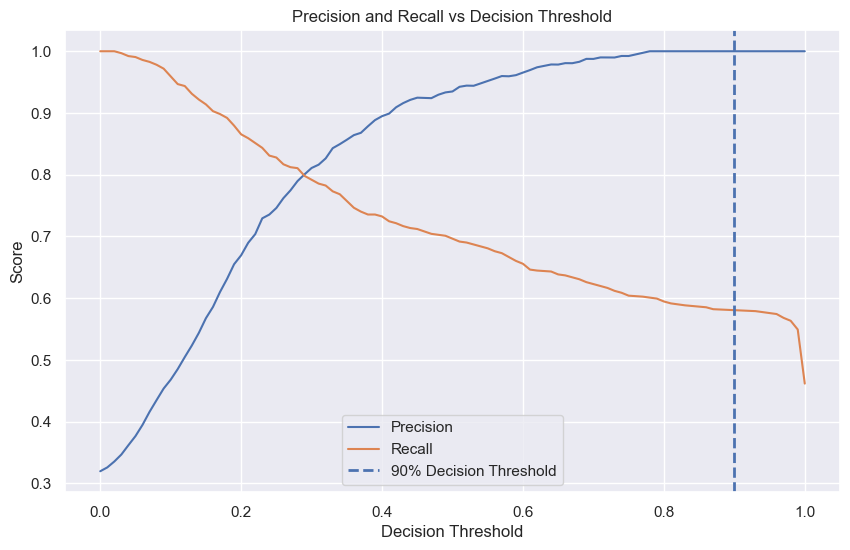

In [6]:
# ==========================================
# 4A. RAW PROBABILITIES
# ==========================================

# Get probability for both classes
y_proba = model.predict_proba(X_test)

# Class 1 = Cheating
cheating_probabilities = y_proba[:, 1]

print("First 10 cheating probabilities:")
print(cheating_probabilities[:10])


# ==========================================
# 4B. CUSTOM DECISION THRESHOLD
# ==========================================

# Default threshold = 50%
y_pred_default = (
    cheating_probabilities >= 0.50
).astype(int)

# Strict threshold = 90%
y_pred_strict = (
    cheating_probabilities >= 0.90
).astype(int)


# ==========================================
# 4C. EVALUATION
# ==========================================

print("🚨 DEFAULT THRESHOLD (0.50)")

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        y_pred_default
    )
)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_default,
        target_names=["Normal", "Cheating"],
        zero_division=0
    )
)


print("\n🛡️ STRICT THRESHOLD (0.90)")

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        y_pred_strict
    )
)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_strict,
        target_names=["Normal", "Cheating"],
        zero_division=0
    )
)


# ==========================================
# 4D. PRECISION-RECALL VISUALIZATION
# ==========================================

precision, recall, thresholds = precision_recall_curve(
    y_test,
    cheating_probabilities
)

plt.figure(figsize=(10, 6))

plt.plot(
    thresholds,
    precision[:-1],
    label="Precision"
)

plt.plot(
    thresholds,
    recall[:-1],
    label="Recall"
)

# Mark 90% probability threshold
plt.axvline(
    x=0.90,
    linestyle="--",
    linewidth=2,
    label="90% Decision Threshold"
)

plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Precision and Recall vs Decision Threshold")

plt.legend()
plt.grid(True)

plt.show()

In [8]:
# ==========================================
# FINAL RESULTS
# ==========================================

default_cm = confusion_matrix(
    y_test,
    y_pred_default
)

strict_cm = confusion_matrix(
    y_test,
    y_pred_strict
)

default_tn, default_fp, default_fn, default_tp = default_cm.ravel()
strict_tn, strict_fp, strict_fn, strict_tp = strict_cm.ravel()

default_precision = precision_score(
    y_test,
    y_pred_default,
    zero_division=0
)

strict_precision = precision_score(
    y_test,
    y_pred_strict,
    zero_division=0
)

default_recall = recall_score(
    y_test,
    y_pred_default,
    zero_division=0
)

strict_recall = recall_score(
    y_test,
    y_pred_strict,
    zero_division=0
)


print("==========================================")
print("       EXECUTIVE MODEL RESULTS")
print("==========================================")

print("\nDEFAULT THRESHOLD = 0.50")
print("False Positives:", default_fp)
print("False Negatives:", default_fn)
print("Precision:", round(default_precision, 4))
print("Recall:", round(default_recall, 4))

print("\nSTRICT THRESHOLD = 0.90")
print("False Positives:", strict_fp)
print("False Negatives:", strict_fn)
print("Precision:", round(strict_precision, 4))
print("Recall:", round(strict_recall, 4))

print("\n==========================================")
print("       THRESHOLD COMPARISON")
print("==========================================")

if strict_fp < default_fp:
    print(
        "✅ False positives decreased after "
        "raising the threshold from 0.50 to 0.90."
    )
else:
    print(
        "ℹ️ False positives did not decrease "
        "on this particular test split."
    )

print(
    "\nThe 10-second rolling features help smooth "
    "short-duration sensor fluctuations."
)

print(
    "\nThe 90% threshold means a student is flagged "
    "only when the model assigns at least 90% "
    "probability to the cheating class."
)

       EXECUTIVE MODEL RESULTS

DEFAULT THRESHOLD = 0.50
False Positives: 31
False Negatives: 194
Precision: 0.9349
Recall: 0.6964

STRICT THRESHOLD = 0.90
False Positives: 0
False Negatives: 268
Precision: 1.0
Recall: 0.5806

       THRESHOLD COMPARISON
✅ False positives decreased after raising the threshold from 0.50 to 0.90.

The 10-second rolling features help smooth short-duration sensor fluctuations.

The 90% threshold means a student is flagged only when the model assigns at least 90% probability to the cheating class.


---
## 🎯 Phase 5: Final Executive Recommendation
*Double-click this cell to edit.*

**To the University Board of Directors:**
Based on the data modeling performed above, I recommend deploying the EduGuard AI proctoring system using the Strict 90% Threshold. By mathematically adjusting the decision boundary, we achieved the following business outcomes:

1. *(Explain what happened to the False Positives when you shifted the threshold)*...
False Positives: When the threshold was increased from 0.50 to 0.90, false positives decreased from 31 to 0, meaning the model became more conservative and avoided incorrectly flagging non-cheating cases.

2. *(Explain why the rolling windows prevented sneezes from being flagged)*...
Rolling Windows: The 10-second rolling features smooth short-duration sensor fluctuations, helping the model avoid treating brief or isolated sensor events, such as a sneeze or temporary movement, as cheating behavior.

**Final Status:** GO — with human review and monitoring. for deployment.